Epoch 0 | Loss: 7.4340
Epoch 200 | Loss: 0.9890
Epoch 400 | Loss: 1.0000
Epoch 600 | Loss: 1.0000
Epoch 800 | Loss: 1.0000


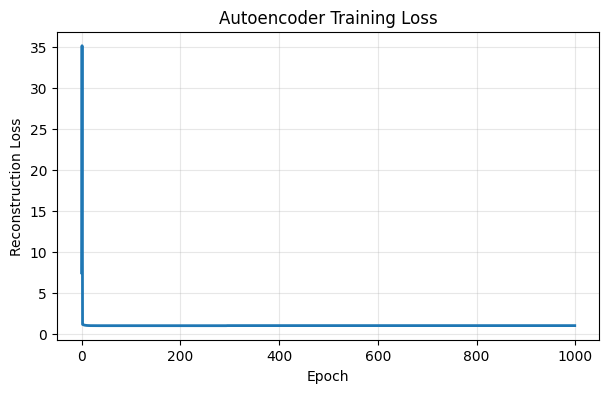

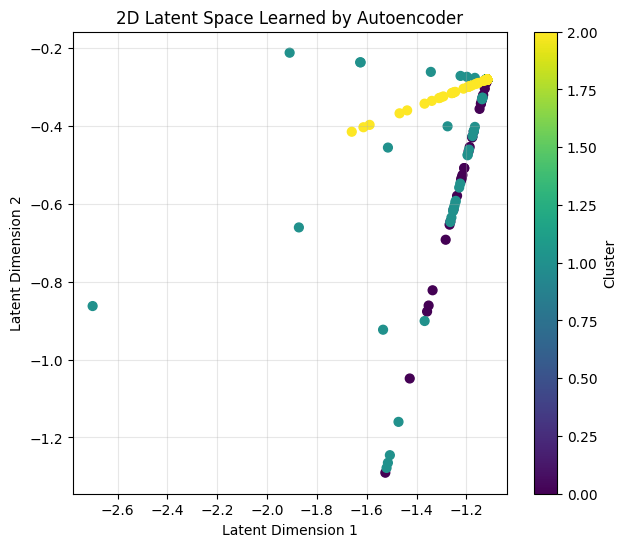

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate data (2D -> compress to 2D via bottleneck)
np.random.seed(42)

# Create 3 clusters
X1 = np.random.randn(100, 2) + [2, 2]
X2 = np.random.randn(100, 2) + [-2, -2]
X3 = np.random.randn(100, 2) + [2, -2]

X = np.vstack([X1, X2, X3])
y = np.array([0]*100 + [1]*100 + [2]*100)

# Normalize
X = (X - X.mean(axis=0)) / X.std(axis=0)

# 2. Autoencoder architecture
input_dim = 2
latent_dim = 2
hidden_dim = 4
lr = 0.05
epochs = 1000

# Weights
W1 = np.random.randn(input_dim, hidden_dim)
b1 = np.zeros((1, hidden_dim))

W2 = np.random.randn(hidden_dim, latent_dim)
b2 = np.zeros((1, latent_dim))

W3 = np.random.randn(latent_dim, hidden_dim)
b3 = np.zeros((1, hidden_dim))

W4 = np.random.randn(hidden_dim, input_dim)
b4 = np.zeros((1, input_dim))

# Activations
relu = lambda x: np.maximum(0, x)
relu_deriv = lambda x: (x > 0).astype(float)

# 3. Training loop
losses = []

for epoch in range(epochs):
    # Forward
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2 # Latest space
    latent = z2

    z3 = latent @ W3 + b3
    a3 = relu(z3)

    output = a3 @ W4 + b4

    # Loss (MSE)
    loss = np.mean((X - output) ** 2)
    losses.append(loss)

    # Backprop
    d_out = 2 * (output - X) / len(X)

    dW4 = a3.T @ d_out
    db4 = d_out.sum(axis=0, keepdims=True)

    da3 = d_out @ W4.T
    dz3 = da3 * relu_deriv(z3)

    dW3 = latent.T @ dz3
    db3 = dz3.sum(axis=0, keepdims=True)

    d_latent = dz3 @ W3.T

    dW2 = a1.T @ d_latent
    db2 = d_latent.sum(axis=0, keepdims=True)

    da1 = d_latent @ W2.T
    dz1 = da1 * relu_deriv(z1)

    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)

    # Update
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    W3 -= lr * dW3
    b3 -= lr * db3
    W4 -= lr * dW4
    b4 -= lr * db4

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

# Visualization
# 1. Loss Curve
plt.figure(figsize=(7,4))
plt.plot(losses, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Autoencoder Training Loss")
plt.grid(alpha=0.3)
plt.show()

# 2. Latent Space
plt.figure(figsize=(7,6))
plt.scatter(latent[:,0], latent[:,1], c=y, cmap="viridis", s=40)
plt.colorbar(label="Cluster")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D Latent Space Learned by Autoencoder")
plt.grid(alpha=0.3)
plt.show()